<a href="https://colab.research.google.com/github/spokenprim618/cmp-415/blob/main/Copy_of_Homework04_LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 4 Logistic Regression

For this homework, you are given a data set on students' exam scores and whether they are admitted to a program. Please complete the following tasks to build a logistic regression model that can be used to predict future admissions.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
url = "https://raw.githubusercontent.com/ch00226855/CMP414765Fall2022/main/data/ExamScores.txt"
data = pd.read_csv(url, names=["Exam1", "Exam2", "Admitted"])
print("Shape:", data.shape)
data.head()
data.info()

Shape: (100, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Exam1     100 non-null    float64
 1   Exam2     100 non-null    float64
 2   Admitted  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


(1) Split the data set into `data_train` (80%) and `data_test` (20%)

In [ ]:
from sklearn.model_selection import train_test_split
data_train, df_test = train_test_split(data, test_size=0.20)
print(data_train.shape, df_test.shape)

(80, 3) (20, 3)


(3) Use the `LogisticRegression` class from `sklearn` to train a logistic regression model on the training set.

In [ ]:
# logistic regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
input_cols = data_train.columns[:2]
model.fit(data_train[input_cols], data_train['Admitted'])

LogisticRegression()

(2) Create a scatter plot for `data_train`. Use different colors to distinguish admitted students and not-admitted students.

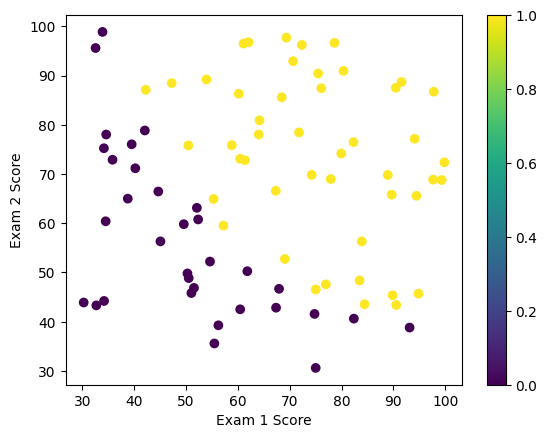

In [ ]:
# Draw scatter plot
plt.scatter(data_train['Exam1'], data_train['Exam2'], c=data_train['Admitted'])
plt.colorbar()
plt.xlabel("Exam 1 Score")
plt.ylabel("Exam 2 Score")
plt.show()

(4) Visualize the decision boundary of the model.

x0 shape: (100, 100) x1 shape: (100, 100)
X_new shape: (10000, 2)
First 5 rows of X_new:
 [[25.         25.        ]
 [25.80808081 25.        ]
 [26.61616162 25.        ]
 [27.42424242 25.        ]
 [28.23232323 25.        ]]
y_new_prob shape: (10000, 2)
First 5 rows of y_new_prob:
 [[9.99999923e-01 7.66203699e-08]
 [9.99999907e-01 9.31548320e-08]
 [9.99999887e-01 1.13257384e-07]
 [9.99999862e-01 1.37698011e-07]
 [9.99999833e-01 1.67412855e-07]]
indices (number of elements found): 41
X_boundary shape: (41, 2)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


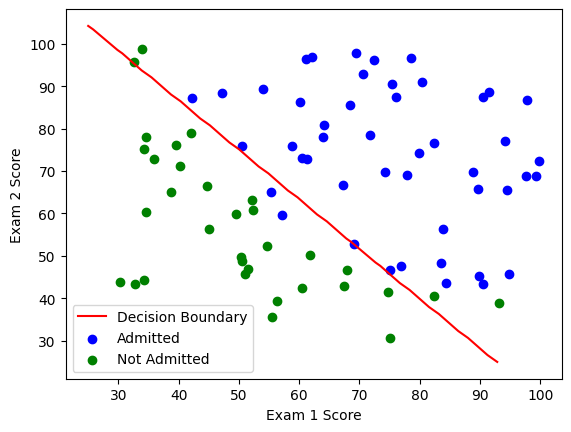

In [ ]:
# 1. Create a grid of points
x0, x1 = np.meshgrid(np.linspace(25, 105, 100),
                     np.linspace(25, 105, 100))
print("x0 shape:", x0.shape, "x1 shape:", x1.shape)

# 2. Obtain prediction probabilities
X_new = np.hstack([x0.reshape([-1, 1]), x1.reshape([-1, 1])])
print("X_new shape:", X_new.shape)
print("First 5 rows of X_new:\n", X_new[:5])
y_new_prob = model.predict_proba(X_new)
print("y_new_prob shape:", y_new_prob.shape)
print("First 5 rows of y_new_prob:\n", y_new_prob[:5])

# 3. Find boundary points.
indices = np.where((y_new_prob[:, 1] > 0.49) & (y_new_prob[:, 1] < 0.51))
print("indices (number of elements found):", len(indices[0]))

X_boundary = X_new[indices]
print("X_boundary shape:", X_boundary.shape)



# 4. Plot boundary
plt.plot(X_boundary[:, 0], X_boundary[:, 1], color='red', label='Decision Boundary')

index_Admitted = (data_train['Admitted'] == 1)
index_not_Admitted = (data_train['Admitted'] == 0)


plt.scatter(data_train.loc[index_Admitted, 'Exam1'],
            data_train.loc[index_Admitted, 'Exam2'],
            c='blue',
            label='Admitted')
plt.scatter(data_train.loc[index_not_Admitted, 'Exam1'],
            data_train.loc[index_not_Admitted, 'Exam2'],
            c='green',
            label='Not Admitted')
plt.xlabel("Exam 1 Score")
plt.ylabel("Exam 2 Score")
plt.legend()
plt.show()

(5) Calculate the accuracy, precision, and recall on the test set.

In [ ]:
#prediction accuracy on test set
from sklearn.metrics import accuracy_score
predictions = model.predict(df_test[input_cols])
print("Predictions:", predictions)
y_true = df_test['Admitted']
print("True values:", y_true.values)
acc = accuracy_score(y_true, predictions)
print("Accuracy:", acc)


Predictions: [0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1]
True values: [0 0 1 0 0 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1]
Accuracy: 0.85


In [ ]:
# precision - recall
from sklearn.metrics import precision_score, recall_score

precision = precision_score(df_test['Admitted'], predictions)
recall = recall_score(df_test['Admitted'], predictions)
print("Precision:", precision)
print("Recall:", recall)

Precision: 0.8571428571428571
Recall: 0.9230769230769231


In [ ]:
#  F1 score
from sklearn.metrics import f1_score
f1 = f1_score(df_test['Admitted'], predictions)
print("F1-score:", f1)
f1 = 2 / (1 / precision + 1 / recall)
print(f1)

F1-score: 0.8888888888888888
0.8888888888888888


(6) (Optional for undergraduates) Modify the visualization in (4) to show how the model's output changes across the range of input exam scores.

In [ ]:
#find with all values instead of a line use color

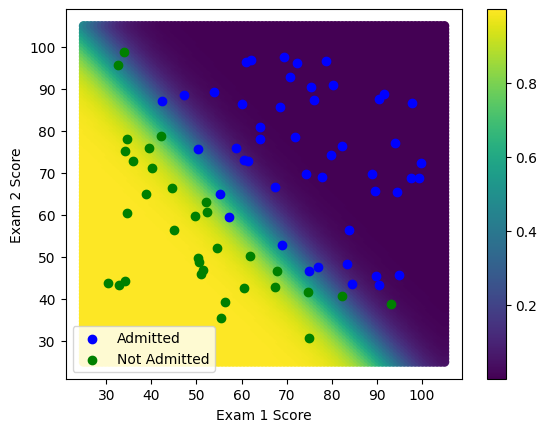

In [ ]:
# 5. Plot probabilities
plt.scatter(X_new[:, 0], X_new[:, 1], c=y_new_prob[:, 0])
plt.colorbar()
plt.scatter(data_train.loc[index_Admitted, 'Exam1'],
            data_train.loc[index_Admitted, 'Exam2'],
            c='blue',
            label='Admitted')
plt.scatter(data_train.loc[index_not_Admitted, 'Exam1'],
            data_train.loc[index_not_Admitted, 'Exam2'],
            c='green',
            label='Not Admitted')
plt.xlabel("Exam 1 Score")
plt.ylabel("Exam 2 Score")
plt.legend()
plt.show()